# Experiment 2 — Training Intensity Prediction

**Research question:** Can we recover the coaching staff's implicit load-assignment policy from observable morning state? Can the model serve as a Readiness to Train proxy?

**Target:** `Training Intensity Yesterday` (continuous [0, 1), `target_horizon=1`)
**Covariates:** Morning wellness, ACWR, GPS history, schedule position, Player ID
**Models:** Ridge Regression, XGBoost (GPU), CatBoost (GPU), TabPFN (GPU)

---

### Table of Contents

| Section | Content |
|---------|---------|
| **0. Imports & Configuration** | Libraries, experiment runner, covariates, lags, GPU overrides |
| **1. Diagnostic EDA** | Dataset scope, target distribution, feature correlations, player/position effects |
| **2. Experiment A — Raw Training Intensity** | All 4 models × 4 lags, comparison table, RMSE/R² charts, best model, feature importance, SHAP, per-player breakdown |
| **3. Summary** | Raw results table (no interpretations) |


---
## Configuration


In [1]:
# ============================================================
#  EXPERIMENT 2 CONFIGURATION
# ============================================================

# --- Lag values to compare -------------------------------------------
LAGS = [1, 2, 3]

# --- Train / test / validation split ---------------------------------
TEST_SIZE = 0.2
VAL_SIZE  = 0.1

# --- Predictor columns -----------------------------------------------
# Only morning-assessment variables (available BEFORE the session).
# 'Training Intensity Yesterday' is the TARGET and must NOT appear here.
COVARIATES = [
    # Morning wellness composites
    'Physical State',                        # Morning composite: fatigue/soreness/readiness
    'Mental State',                          # Morning composite: mood/stress/sleep
    # Yesterday's load -- ACWR ratios
    'Total Distance (ACWR) Yesterday',       # Workload: ACWR total distance
    'High Speed Distance (ACWR) Yesterday',  # Workload: ACWR high-speed distance
    'Any ACWR Danger',                       # Binary: any ACWR > 1.5
    # Yesterday's load -- GPS benchmark %
    'Total Distance % Yesterday',            # GPS total distance as % of match benchmark
    'High Speed Distance % Yesterday',       # GPS high-speed distance as % of match benchmark
    # Yesterday's load -- subjective
    'Perceived Exertion Yesterday',          # RPE z-score
    # Yesterday's raw GPS/HR
    'Total Minutes Yesterday',               # Raw session volume
    'Avg Heart Rate Yesterday',              # Average heart rate
    'Heart Rate Exertion Yesterday',         # Heart rate exertion index
    # Temporal context
    'Days Since Game', 'Days Until Match',   # Schedule position
    # Player profile
    'Player ID',                             # Nominal player identifier
]

# --- Models to run ---------------------------------------------------
MODELS = ['lin_reg', 'xgboost', 'catboost', 'tabpfn']

# --- GPU overrides (passed to run_experiment as model_kwargs) --------
# These override the MODEL_DEFAULTS in scripts/Experiment2.py.
# Switch to 'cpu' / 'CPU' if no CUDA GPU is available.
GPU_OVERRIDES = {
    'xgboost':  {'device': 'cuda'},          # XGBoost >= 2.0
    'catboost': {'task_type': 'GPU'},         # CatBoost native CUDA
    'tabpfn':   {'device': 'cuda',           # TabPFN GPU inference
                 'ignore_pretraining_limits': True},  # bypass 1k-row CPU cap
}

# ============================================================
print(f"Lags to compare:  {LAGS}")
print(f"Models to run:    {MODELS}")
print(f"Covariates:       {len(COVARIATES)}")
print(f"Test / Val split: {TEST_SIZE} / {VAL_SIZE}")
print(f"GPU overrides:    {GPU_OVERRIDES}")




Lags to compare:  [1, 2, 3]
Models to run:    ['lin_reg', 'xgboost', 'catboost', 'tabpfn']
Covariates:       14
Test / Val split: 0.2 / 0.1
GPU overrides:    {'xgboost': {'device': 'cuda'}, 'catboost': {'task_type': 'GPU'}, 'tabpfn': {'device': 'cuda', 'ignore_pretraining_limits': True}}


## 0. Imports


In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.extend([str(ROOT), str(ROOT / 'src'), str(ROOT / 'scripts')])

from Experiment2 import run_experiment

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Setup complete.")


Setup complete.


---
## 1. Diagnostic EDA

Before running any model, we analyse the prediction task.


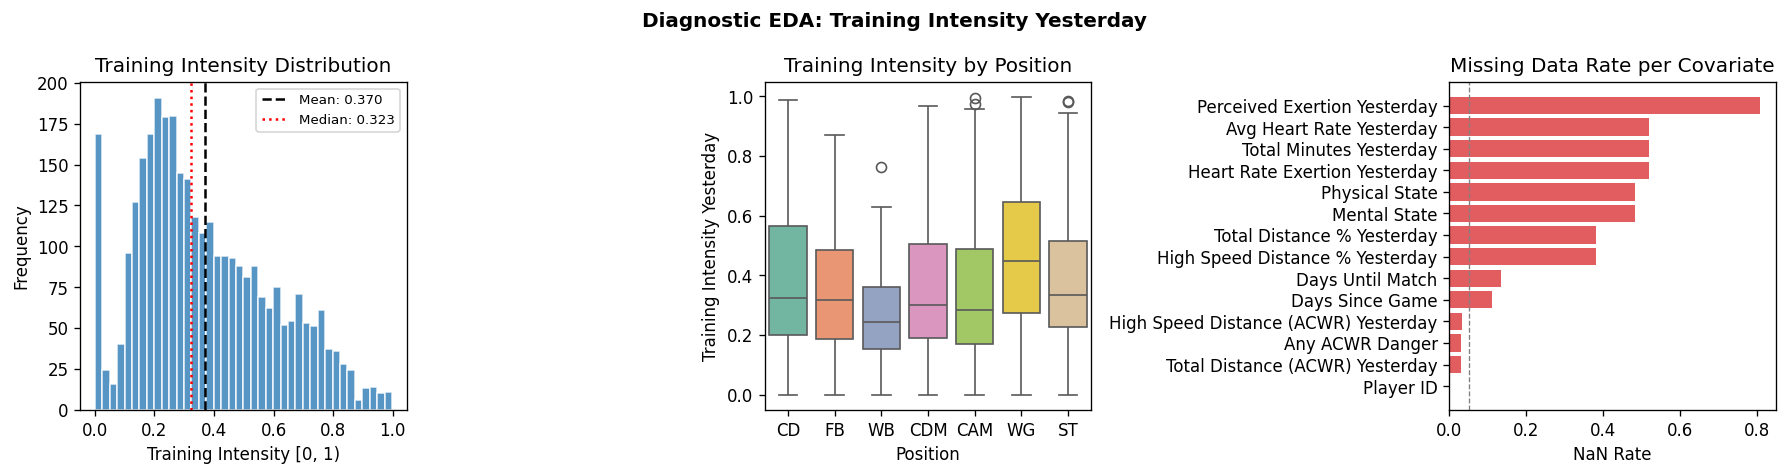

Dataset shape:     (5234, 46)
Training Intensity: 3237 non-NaN (61.8%)
  Mean:   0.3699
  Median: 0.3230
  Std:    0.2250
  Min:    0.0000
  Max:    0.9979

Correlations with Training Intensity Yesterday:
  High Speed Distance % Yesterday                     r = +0.884
  Total Distance % Yesterday                          r = +0.843
  Total Minutes Yesterday                             r = +0.629
  Perceived Exertion Yesterday                        r = +0.549
  Heart Rate Exertion Yesterday                       r = +0.522
  High Speed Distance (ACWR) Yesterday                r = +0.491
  Any ACWR Danger                                     r = +0.379
  Total Distance (ACWR) Yesterday                     r = +0.304
  Avg Heart Rate Yesterday                            r = +0.281
  Physical State                                      r = -0.259
  Mental State                                        r = -0.227
  Days Since Game                                     r = -0.169
  Player ID    

In [3]:
# -- Diagnostic EDA: Training Intensity distribution, NaN rates, correlations --
RTT_PATH = ROOT / "data" / "processed" / "RTT.xlsx"
df_eda = pd.read_excel(RTT_PATH)
df_eda["Date"] = pd.to_datetime(df_eda["Date"])

ti = df_eda['Training Intensity Yesterday'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
ax = axes[0]
ax.hist(ti, bins=40, color='#2c7bb6', alpha=0.8, edgecolor='white')
ax.axvline(ti.mean(), color='black', ls='--', lw=1.5, label=f'Mean: {ti.mean():.3f}')
ax.axvline(ti.median(), color='red', ls=':', lw=1.5, label=f'Median: {ti.median():.3f}')
ax.set_xlabel('Training Intensity [0, 1)')
ax.set_ylabel('Frequency')
ax.set_title('Training Intensity Distribution')
ax.legend(fontsize=8)

# Per-position boxplot
ax = axes[1]
pos_order = ['CD', 'FB', 'WB', 'CDM', 'CAM', 'WG', 'ST']
df_plot = df_eda[df_eda['Training Intensity Yesterday'].notna()].copy()
pos_present = [p for p in pos_order if p in df_plot['Position'].values]
sns.boxplot(data=df_plot, x='Position', y='Training Intensity Yesterday',
            order=pos_present, ax=ax, palette='Set2')
ax.set_title('Training Intensity by Position')

# NaN rate per covariate
ax = axes[2]
nan_rates = df_eda[COVARIATES].isnull().mean().sort_values(ascending=True)
ax.barh(nan_rates.index, nan_rates.values, color='#d7191c', alpha=0.7)
ax.set_xlabel('NaN Rate')
ax.set_title('Missing Data Rate per Covariate')
ax.axvline(0.05, color='grey', ls='--', lw=0.8)

plt.suptitle('Diagnostic EDA: Training Intensity Yesterday', fontweight='bold')
plt.tight_layout()
plt.show()

# Key stats
print(f'Dataset shape:     {df_eda.shape}')
print(f'Training Intensity: {ti.count()} non-NaN ({ti.count()/len(df_eda)*100:.1f}%)')
print(f'  Mean:   {ti.mean():.4f}')
print(f'  Median: {ti.median():.4f}')
print(f'  Std:    {ti.std():.4f}')
print(f'  Min:    {ti.min():.4f}')
print(f'  Max:    {ti.max():.4f}')

# Correlations with target
print('\nCorrelations with Training Intensity Yesterday:')
numeric_covs = [c for c in COVARIATES if c in df_eda.columns and df_eda[c].dtype in ['float64', 'int64']]
corrs = df_eda[numeric_covs + ['Training Intensity Yesterday']].corr()['Training Intensity Yesterday'].drop('Training Intensity Yesterday')
for feat, r in corrs.abs().sort_values(ascending=False).items():
    sign = '+' if corrs[feat] > 0 else '-'
    print(f'  {feat:50s}  r = {sign}{r:.3f}')





---
## 2. Experiment A — Raw Training Intensity

Predict absolute Training Intensity Yesterday from morning covariates.

### 2.1 Run all models × all lags


In [4]:
all_results = {m: {} for m in MODELS}

for model_type in MODELS:
    # Apply GPU overrides defined in the CONFIGURATION cell
    gpu_kwargs = GPU_OVERRIDES.get(model_type, {})
    for lag in LAGS:
        print(f"\n>>> {model_type}  lag={lag}  {gpu_kwargs or '(no GPU override)'}")
        all_results[model_type][lag] = run_experiment(
            covariates=COVARIATES,
            lag=lag,
            model_type=model_type,
            test_size=TEST_SIZE,
            val_size=VAL_SIZE,
            verbose=True,
            **gpu_kwargs,
        )

print("\nAll experiments complete.")



>>> lin_reg  lag=1  (no GPU override)
Experiment 2: Treatment Policy Modelling
Predict today's Training Intensity from morning covariates
  Target:      Training Intensity Yesterday  (target_horizon=1)
  Model:       lin_reg
  Lag:         1
  Covariates:  14
               . Physical State
               . Mental State
               . Total Distance (ACWR) Yesterday
               . High Speed Distance (ACWR) Yesterday
               . Any ACWR Danger
               . Total Distance % Yesterday
               . High Speed Distance % Yesterday
               . Perceived Exertion Yesterday
               . Total Minutes Yesterday
               . Avg Heart Rate Yesterday
               . Heart Rate Exertion Yesterday
               . Days Since Game
               . Days Until Match
               . Player ID
  Test size:   0.2
  Val size:    0.1

  Test  RMSE:  0.1960  (null: 0.2056)
  Train RMSE:  0.1995
  R2:          0.0631
  Pearson r:   0.3842  (p = 0.0000)
  MAE:         0.1620

### 2.2 Comparison table


In [5]:
rows = []
for model_type in MODELS:
    for lag in LAGS:
        m = all_results[model_type][lag]['metrics']
        rows.append({
            'Model':       model_type,
            'Lag':         lag,
            'RMSE':        round(m['rmse'],       4),
            'Null RMSE':   round(m['null_rmse'],  4),
            'Skill (%)':   round((1 - m['rmse'] / m['null_rmse']) * 100, 1),
            'MAE':         round(m['mae'],        4),
            'R2':          round(m['r2'],         4),
            'Pearson r':   round(m['pearson_r'],  4),
            'Train RMSE':  round(m['train_rmse'], 4),
            'N test':      m['n_test'],
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))


   Model  Lag   RMSE  Null RMSE  Skill (%)    MAE     R2  Pearson r  Train RMSE  N test
 lin_reg    1 0.1960     0.2056        4.7 0.1620 0.0631     0.3842      0.1995     634
 lin_reg    2 0.1951     0.2056        5.1 0.1623 0.0717     0.3974      0.1972     634
 lin_reg    3 0.1942     0.2056        5.6 0.1623 0.0801     0.3955      0.1960     634
 xgboost    1 0.1630     0.2056       20.7 0.1289 0.3519     0.6015      0.1120     634
 xgboost    2 0.1590     0.2056       22.7 0.1263 0.3831     0.6291      0.1083     634
 xgboost    3 0.1594     0.2056       22.5 0.1255 0.3801     0.6266      0.1076     634
catboost    1 0.1598     0.2056       22.3 0.1272 0.3770     0.6196      0.1005     634
catboost    2 0.1635     0.2056       20.5 0.1302 0.3480     0.6012      0.1251     634
catboost    3 0.1581     0.2056       23.1 0.1266 0.3901     0.6439      0.1297     634
  tabpfn    1 0.1564     0.2056       23.9 0.1224 0.4032     0.6364      0.0821     634
  tabpfn    2 0.1607     0.2056 

### 2.3 Visualisation — RMSE and R²


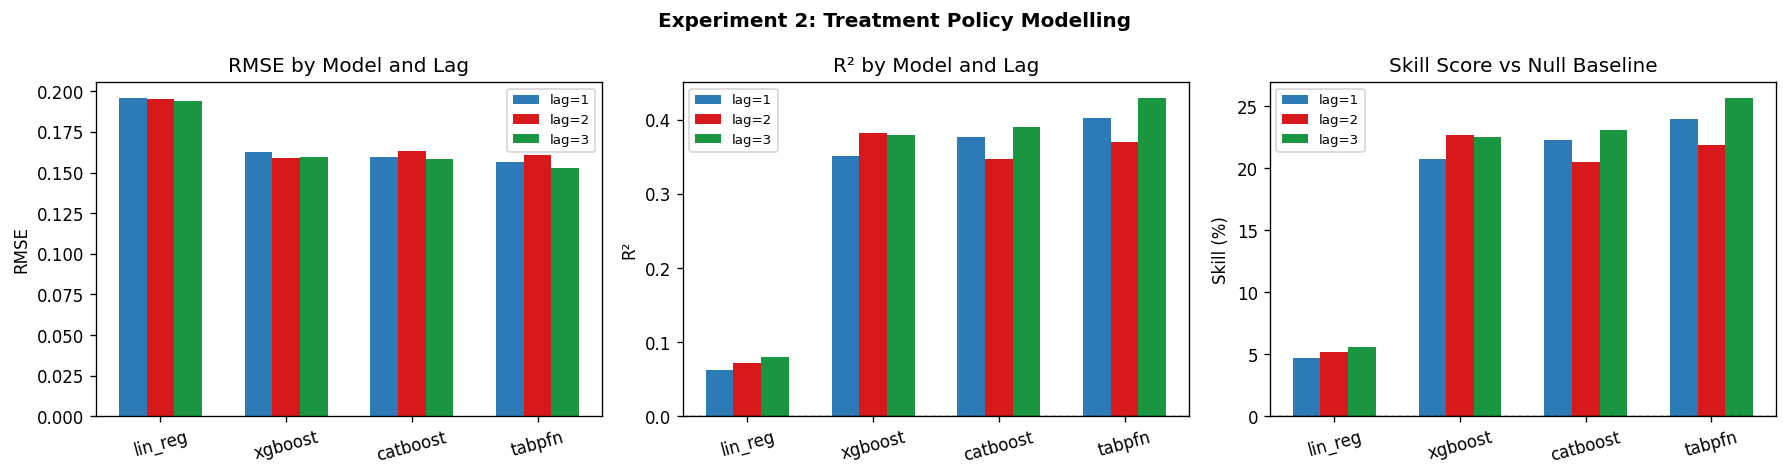

In [6]:
LAG_COLORS = {0: '#fdae61', 1: '#2c7bb6', 2: '#d7191c', 3: '#1a9641'}
x = np.arange(len(MODELS))
n_lags = len(LAGS)
w = 0.22

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- RMSE vs Null ---
ax = axes[0]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    rmses  = [all_results[m][lag]['metrics']['rmse']      for m in MODELS]
    ax.bar(x + offset, rmses, w, label=f'lag={lag}', color=LAG_COLORS[lag])
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('RMSE'); ax.set_title('RMSE by Model and Lag')
ax.legend(fontsize=8)

# --- R² ---
ax = axes[1]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    r2s = [all_results[m][lag]['metrics']['r2'] for m in MODELS]
    ax.bar(x + offset, r2s, w, label=f'lag={lag}', color=LAG_COLORS[lag])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('R²'); ax.set_title('R² by Model and Lag')
ax.legend(fontsize=8)

# --- Skill (%) ---
ax = axes[2]
for i, lag in enumerate(LAGS):
    offset = (i - (n_lags - 1) / 2) * w
    skills = [
        (1 - all_results[m][lag]['metrics']['rmse'] /
             all_results[m][lag]['metrics']['null_rmse']) * 100
        for m in MODELS
    ]
    ax.bar(x + offset, skills, w, label=f'lag={lag}', color=LAG_COLORS[lag])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=15)
ax.set_ylabel('Skill (%)')
ax.set_title('Skill Score vs Null Baseline')
ax.legend(fontsize=8)

fig.suptitle('Experiment 2: Treatment Policy Modelling', fontweight='bold')
plt.tight_layout()
plt.show()



### 2.4 Lag effect


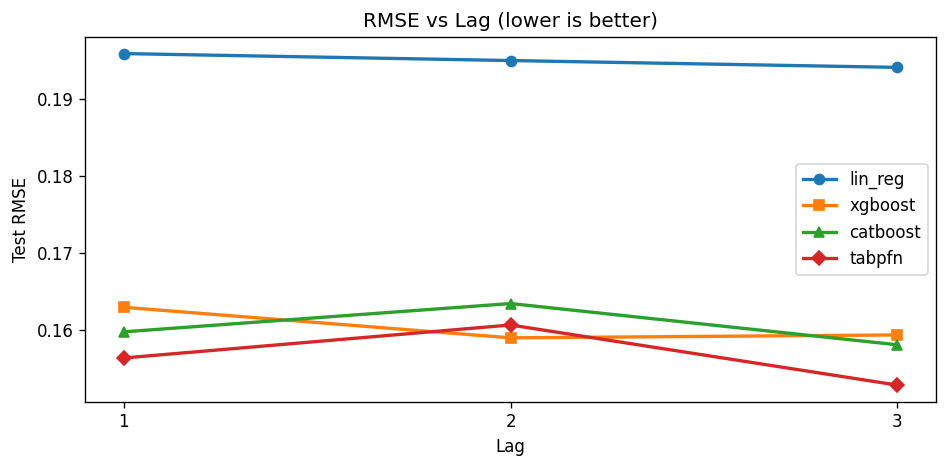

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
markers = ['o', 's', '^', 'D']
for j, model_type in enumerate(MODELS):
    rmses = [all_results[model_type][lag]['metrics']['rmse'] for lag in LAGS]
    ax.plot(LAGS, rmses, marker=markers[j % len(markers)],
            label=model_type, lw=2)

ax.set_xlabel('Lag'); ax.set_ylabel('Test RMSE')
ax.set_title('RMSE vs Lag (lower is better)')
ax.set_xticks(LAGS)
ax.legend()
plt.tight_layout()
plt.show()


### 2.5 Best model — predicted vs actual


Best: tabpfn  lag=3  RMSE=0.1529  R2=0.4298


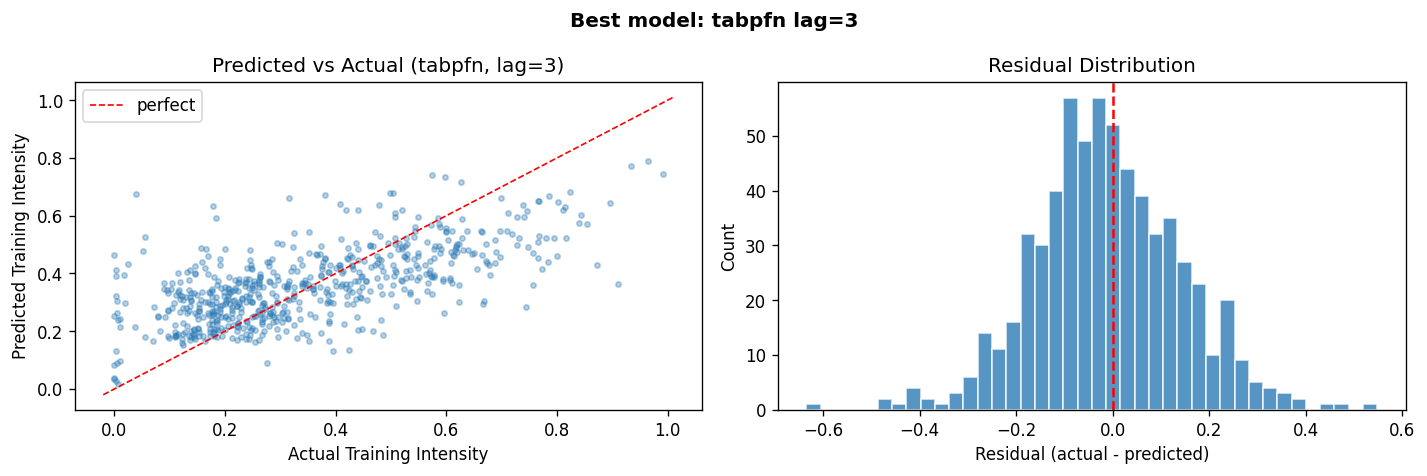

In [8]:
# Find the (model, lag) combination with lowest test RMSE
best = min(
    [(m, l) for m in MODELS for l in LAGS],
    key=lambda ml: all_results[ml[0]][ml[1]]['metrics']['rmse']
)
best_model, best_lag = best
res = all_results[best_model][best_lag]
print(f"Best: {best_model}  lag={best_lag}  "
      f"RMSE={res['metrics']['rmse']:.4f}  R2={res['metrics']['r2']:.4f}")

y_true = res['y_test_true']
y_pred = res['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.35, s=10, color='#2c7bb6')
lims = [min(y_true.min(), y_pred.min()) - 0.02,
        max(y_true.max(), y_pred.max()) + 0.02]
ax.plot(lims, lims, 'r--', lw=1, label='perfect')
ax.set_xlabel('Actual Training Intensity')
ax.set_ylabel('Predicted Training Intensity')
ax.set_title(f'Predicted vs Actual ({best_model}, lag={best_lag})')
ax.legend()

ax = axes[1]
residuals = y_true - y_pred
ax.hist(residuals, bins=40, color='#2c7bb6', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.suptitle(f'Best model: {best_model} lag={best_lag}', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.6 Feature importances


Computing permutation importance for tabpfn (10 repeats)...


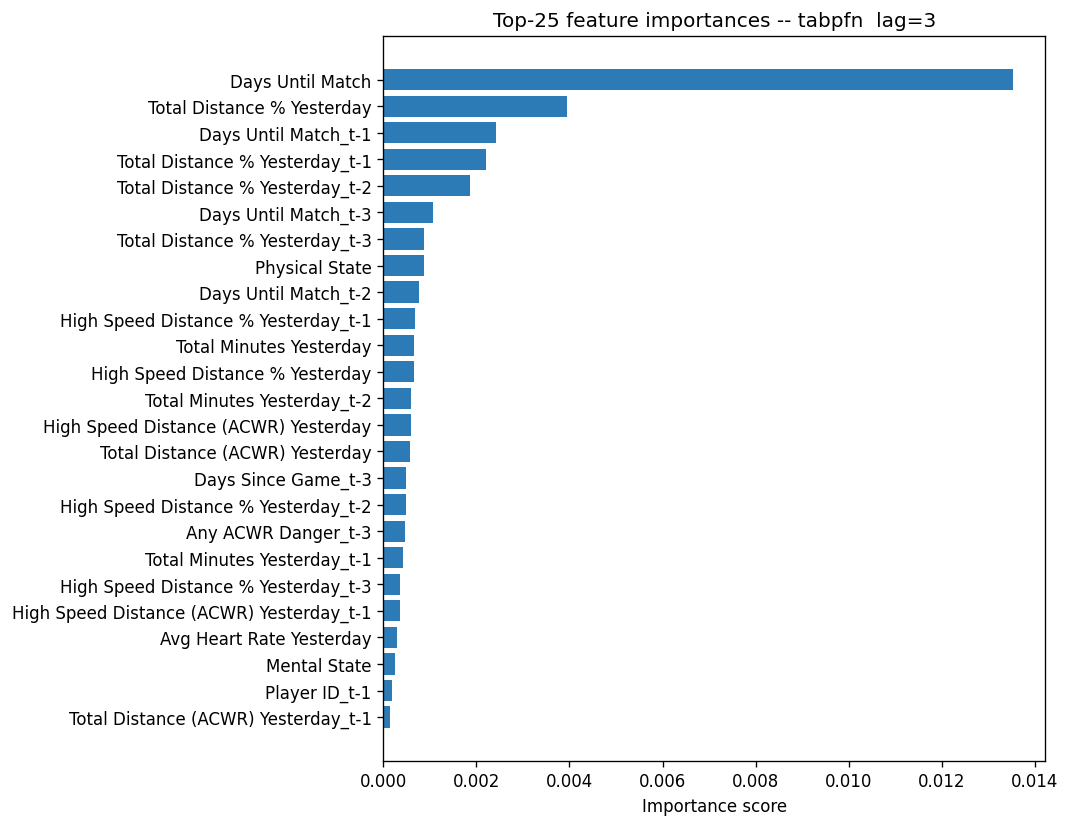

Top 10 features by importance:
                            feature  importance
                   Days Until Match    0.013538
         Total Distance % Yesterday    0.003950
               Days Until Match_t-1    0.002423
     Total Distance % Yesterday_t-1    0.002200
     Total Distance % Yesterday_t-2    0.001862
               Days Until Match_t-3    0.001063
     Total Distance % Yesterday_t-3    0.000881
                     Physical State    0.000880
               Days Until Match_t-2    0.000776
High Speed Distance % Yesterday_t-1    0.000682


In [9]:
weights = res.get('model_weights', {})
fnames  = res.get('feature_names', [])

imps = weights.get('importances') or weights.get('feature_importances')
if imps is None and 'coefficients' in weights:
    raw_coef = np.array(weights['coefficients']).flatten()
    imps = np.abs(raw_coef)

# For TabPFN (no native importances), use sklearn permutation importance
if imps is None and res.get('trained_model') is not None:
    from sklearn.inspection import permutation_importance as sklearn_perm_imp
    trained = res['trained_model']
    X_test_imp = res.get('X_test')
    y_test_imp = res.get('y_test_true')
    if X_test_imp is not None and y_test_imp is not None:
        print(f"Computing permutation importance for {best_model} (10 repeats)...")
        perm_result = sklearn_perm_imp(trained, X_test_imp, y_test_imp,
                                        n_repeats=10, random_state=42,
                                        scoring='neg_mean_squared_error')
        imps = perm_result.importances_mean
        fnames = res.get('feature_names', [])

if imps is not None and len(fnames) > 0:
    imp_arr = np.array(imps).flatten()
    if len(imp_arr) != len(fnames):
        fnames = [f'feature_{i}' for i in range(len(imp_arr))]
    imp_df = pd.DataFrame({'feature': fnames, 'importance': imp_arr})
    imp_df = imp_df.sort_values('importance', ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#2c7bb6')
    ax.set_xlabel('Importance score')
    ax.set_title(f'Top-25 feature importances -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()

    print("Top 10 features by importance:")
    print(imp_df.head(10).to_string(index=False))
else:
    print("No importances available for this model type.")




### 2.7 SHAP / Permutation importance analysis


TabPFN detected -- using sklearn permutation importance (not SHAP).
Computing permutation importance (10 repeats, 634 test samples)...


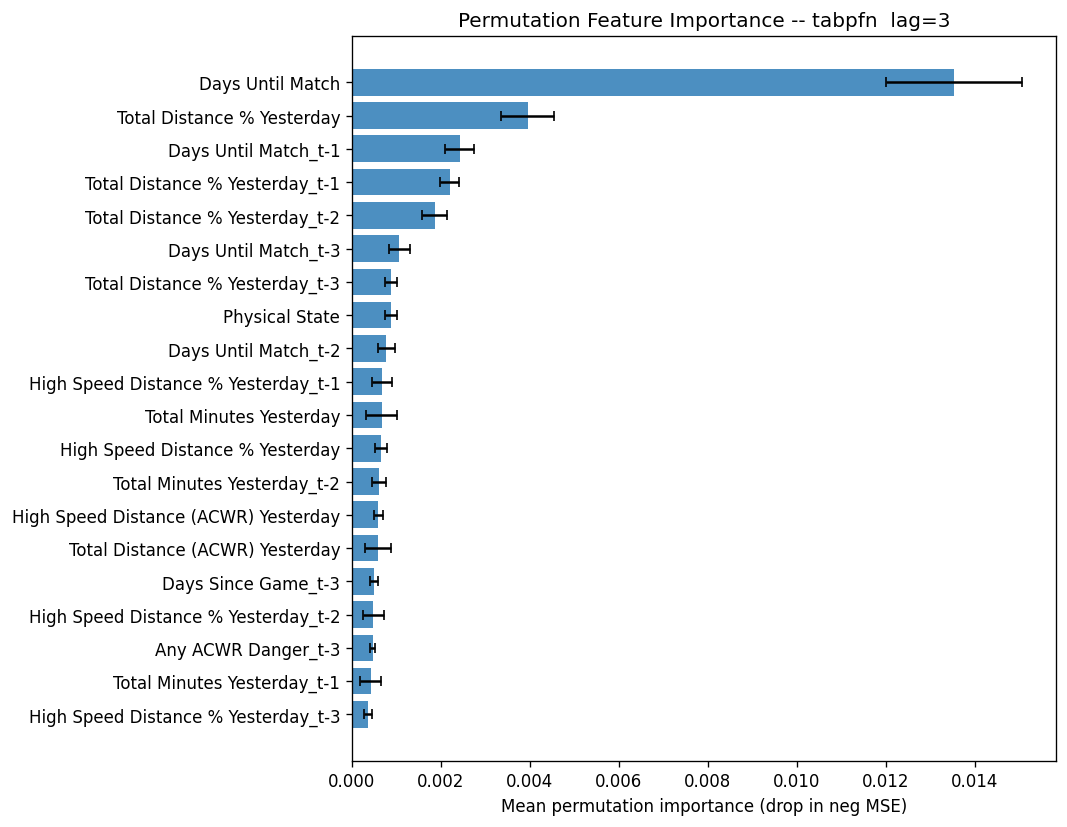

Top 10 features by permutation importance:
                            feature  importance_mean  importance_std
                   Days Until Match         0.013538        0.001539
         Total Distance % Yesterday         0.003950        0.000596
               Days Until Match_t-1         0.002423        0.000319
     Total Distance % Yesterday_t-1         0.002200        0.000215
     Total Distance % Yesterday_t-2         0.001862        0.000285
               Days Until Match_t-3         0.001063        0.000232
     Total Distance % Yesterday_t-3         0.000881        0.000142
                     Physical State         0.000880        0.000141
               Days Until Match_t-2         0.000776        0.000190
High Speed Distance % Yesterday_t-1         0.000682        0.000224


In [10]:
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("SHAP not installed. Install with: pip install shap")

shap_res = all_results[best_model][best_lag]
trained  = shap_res.get('trained_model')
X_train  = shap_res.get('X_train')
X_test   = shap_res.get('X_test')
feature_names = shap_res.get('feature_names', [])

if trained is None or X_test is None:
    print(f"Importance analysis skipped: trained_model or X_test not available for {best_model}.")
elif best_model == 'tabpfn':
    from sklearn.inspection import permutation_importance as sklearn_perm_imp
    print(f"TabPFN detected -- using sklearn permutation importance (not SHAP).")
    print(f"Computing permutation importance (10 repeats, {X_test.shape[0]} test samples)...")
    y_test_shap = shap_res.get('y_test_true')
    perm_result = sklearn_perm_imp(trained, X_test, y_test_shap,
                                    n_repeats=10, random_state=42,
                                    scoring='neg_mean_squared_error')
    fn = feature_names if len(feature_names) == X_test.shape[1] else [f'f_{i}' for i in range(X_test.shape[1])]
    perm_df = pd.DataFrame({
        'feature': fn,
        'importance_mean': perm_result.importances_mean,
        'importance_std':  perm_result.importances_std,
    }).sort_values('importance_mean', ascending=False)
    top_n = min(20, len(perm_df))
    top = perm_df.head(top_n)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top['feature'][::-1], top['importance_mean'][::-1],
            xerr=top['importance_std'][::-1],
            color='#2c7bb6', alpha=0.85,
            error_kw=dict(ecolor='black', capsize=3))
    ax.set_xlabel('Mean permutation importance (drop in neg MSE)')
    ax.set_title(f'Permutation Feature Importance -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    print("Top 10 features by permutation importance:")
    print(perm_df.head(10).to_string(index=False))
elif shap_available:
    feature_names_shap = (list(X_test.columns)
                         if hasattr(X_test, 'columns')
                         else feature_names)
    if best_model in ('xgboost', 'catboost'):
        explainer   = shap.TreeExplainer(trained)
        shap_values = explainer.shap_values(X_test)
    else:
        explainer   = shap.LinearExplainer(trained, X_train)
        shap_values = explainer.shap_values(X_test)
    print("Beeswarm: each dot = one test observation")
    shap.summary_plot(shap_values, X_test,
                      feature_names=feature_names_shap,
                      show=False, max_display=20)
    plt.title(f'SHAP Beeswarm -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    print("Bar: mean absolute SHAP value")
    shap.summary_plot(shap_values, X_test,
                      feature_names=feature_names_shap,
                      plot_type='bar', show=False, max_display=20)
    plt.title(f'SHAP Mean |SHAP| -- {best_model}  lag={best_lag}')
    plt.tight_layout()
    plt.show()
    imp_vals = np.abs(shap_values).mean(axis=0)
    top_idx  = int(np.argmax(imp_vals))
    top_name = (feature_names_shap[top_idx]
                if top_idx < len(feature_names_shap) else str(top_idx))
    print(f"Dependence plot for top feature: '{top_name}'")
    shap.dependence_plot(top_idx, shap_values, X_test,
                         feature_names=feature_names_shap, show=False)
    plt.title(f'SHAP Dependence: {top_name}')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available and model is not TabPFN.")




### 2.8 Per-player breakdown


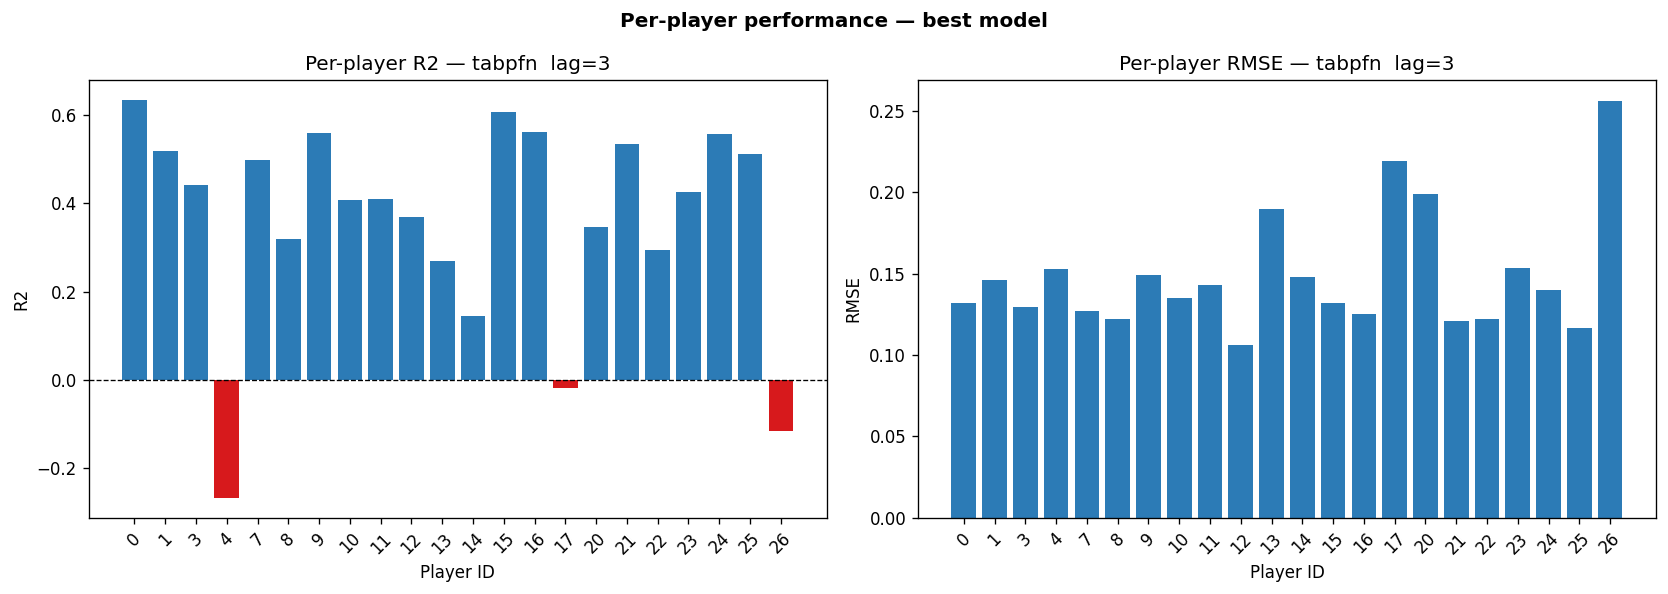


Per-player summary:
            N      RMSE        R2
Player ID                        
0          30  0.131852  0.634467
1          30  0.146236  0.517791
3          31  0.129484  0.441663
4          29  0.152601 -0.267457
7          28  0.127111  0.499107
8          29  0.122276  0.318786
9          30  0.149065  0.559022
10         15  0.134993  0.408090
11         29  0.142809  0.410781
12         30  0.106336  0.369065
13         29  0.189792  0.269769
14         30  0.147869  0.144357
15         30  0.131788  0.607572
16         29  0.125284  0.561277
17         25  0.218975 -0.017181
20         30  0.199036  0.345608
21         29  0.120618  0.533886
22         31  0.122216  0.294770
23         28  0.153481  0.426356
24         30  0.140147  0.556964
25         30  0.116585  0.510937
26         32  0.256007 -0.115041


In [11]:
# Per-player R2 and RMSE bar charts — best model x best lag
best_pp = all_results[best_model][best_lag].get('per_player', {})

if best_pp:
    pp_df = pd.DataFrame([
        {'Player ID': pid,
         'N':    v['n'],
         'RMSE': v['rmse'],
         'R2':   v['r2'] if v['r2'] is not None else float('nan')}
        for pid, v in sorted(best_pp.items())
    ]).set_index('Player ID')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # R2 bar chart
    ax = axes[0]
    colors_r2 = ['#d7191c' if r < 0 else '#2c7bb6'
                 for r in pp_df['R2'].fillna(-1)]
    ax.bar(pp_df.index.astype(str), pp_df['R2'].fillna(0), color=colors_r2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Player ID')
    ax.set_ylabel('R2')
    ax.set_title(f'Per-player R2 — {best_model}  lag={best_lag}')
    ax.tick_params(axis='x', rotation=45)

    # RMSE bar chart
    ax = axes[1]
    ax.bar(pp_df.index.astype(str), pp_df['RMSE'], color='#2c7bb6')
    ax.set_xlabel('Player ID')
    ax.set_ylabel('RMSE')
    ax.set_title(f'Per-player RMSE — {best_model}  lag={best_lag}')
    ax.tick_params(axis='x', rotation=45)

    plt.suptitle('Per-player performance — best model', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nPer-player summary:")
    print(pp_df.to_string())
else:
    print("No per-player breakdown available (meta_test may be missing).")


---
## 3. Summary



In [12]:
try:
    print("=" * 72)
    print("EXPERIMENT 2 -- RESULTS SUMMARY")
    print("=" * 72)
    print()
    print(f"  {'Model':<12} {'Lag':>4} {'RMSE':>8} {'Null':>8} {'R2':>8} {'r':>8} {'MAE':>8} {'N_test':>6}")
    for model_type in MODELS:
        for lag in LAGS:
            m = all_results[model_type][lag]['metrics']
            print(f"  {model_type:<12} {lag:>4} {m['rmse']:>8.4f} {m['null_rmse']:>8.4f} "
                  f"{m['r2']:>8.4f} {m['pearson_r']:>8.4f} {m['mae']:>8.4f} {m['n_test']:>6}")
    print()
    bm, bl = min([(m, l) for m in MODELS for l in LAGS],
                 key=lambda ml: all_results[ml[0]][ml[1]]['metrics']['rmse'])
    bmet = all_results[bm][bl]['metrics']
    print(f"BEST: {bm} lag={bl}")
    for k, v in bmet.items():
        if isinstance(v, float):
            print(f"  {k:<20} {v:.6f}")
        else:
            print(f"  {k:<20} {v}")
    print()
    pp = all_results[bm][bl].get('per_player', {})
    if pp:
        print("PER-PLAYER (best model):")
        for pid, v in sorted(pp.items()):
            r2s = f"{v['r2']:.4f}" if v.get('r2') is not None else 'N/A'
            print(f"  Player {str(pid):<8}  N={v['n']:>4}  RMSE={v['rmse']:.4f}  R2={r2s}")
    print("=" * 72)
except NameError:
    print("[Summary] Run experiment cells first.")




EXPERIMENT 2 -- RESULTS SUMMARY

  Model         Lag     RMSE     Null       R2        r      MAE N_test
  lin_reg         1   0.1960   0.2056   0.0631   0.3842   0.1620    634
  lin_reg         2   0.1951   0.2056   0.0717   0.3974   0.1623    634
  lin_reg         3   0.1942   0.2056   0.0801   0.3955   0.1623    634
  xgboost         1   0.1630   0.2056   0.3519   0.6015   0.1289    634
  xgboost         2   0.1590   0.2056   0.3831   0.6291   0.1263    634
  xgboost         3   0.1594   0.2056   0.3801   0.6266   0.1255    634
  catboost        1   0.1598   0.2056   0.3770   0.6196   0.1272    634
  catboost        2   0.1635   0.2056   0.3480   0.6012   0.1302    634
  catboost        3   0.1581   0.2056   0.3901   0.6439   0.1266    634
  tabpfn          1   0.1564   0.2056   0.4032   0.6364   0.1224    634
  tabpfn          2   0.1607   0.2056   0.3700   0.6156   0.1264    634
  tabpfn          3   0.1529   0.2056   0.4298   0.6582   0.1196    634

BEST: tabpfn lag=3
  mse      